# Códigos para autorizar buscas nas pastas do Drive.

In [773]:
# Conectando O Colab ao Drive para acessar pastas e arquivos.
from google.colab import drive
drive.mount('/content/drive')

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Leitura e manipulação do DataFrame

## Importação e leitura das informações gerais do DataFrame.

In [774]:
# Importar o Pandas para Ler e Manipular o DataFrame
import pandas as pd

# Alterando as configurações do Pandas para exibir o máximo de colunas e não querbrar as linhas.
pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)
# pd.set_option('display.width', None)

# Local do meu arquivo.
train = (r'/content/drive/MyDrive/Colab Notebooks/SCTEC - Materiais e Projetos/Testes de Análises/titanic/train.csv')

# Lendo a Base:
df_train = pd.read_csv(
    train,
    sep=',',
    encoding='utf-8',
    decimal='.',
    low_memory=False
)

# Criando uma cópia do DataFrame desde o início.
df = df_train.copy()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Renomeando as colunas e exibindo as primeiras linhas do DataFrame.

In [775]:
# Renomeando as colunas.
traducao = {
  # "Nome_antigo": "Nome_novo"
    "PassengerId": "Id_Passageiro",
    "Survived"   : "Sobreviveu",
    "Pclass"     : "Classe",
    "Name"       : "Nome",
    "Sex"        : "Sexo",
    "Age"        : "Idade",
    "SibSp"      : "Irmaos_esposa",
    "Parch"      : "Pais_filhos",
    "Ticket"     : "Bilhete",
    "Fare"       : "Tarifa",
    "Cabin"      : "Cabine",
    "Embarked"   : "Porto_embarque"
}

# DataFrame irá receber os novos nomes.
df = df.rename(columns=traducao)

# Novos nomes impressos.
df.head()

,Id_Passageiro,Sobreviveu,Classe,Nome,Sexo,Idade,Irmaos_esposa,Pais_filhos,Bilhete,Tarifa,Cabine,Porto_embarque
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Quem são as colunas com valores nulos e quais linhas elas se encontram.

In [776]:
# Quais colunas tem valores nulos e exibindo só essas colunas com valores nulos.
df_nulos = df.isnull().sum()
df_nulos = df_nulos[df_nulos > 0].sort_values(ascending=False).reset_index(name="Valores")
df_nulos = df_nulos.rename(columns={"index": "Colunas"})

df_nulos

,Colunas,Valores
0,Cabine,687
1,Idade,177
2,Porto_embarque,2


In [777]:
# Exibindo algumas linhas aonde tem valores nulos na coluna Cabine.
cabines_nulas = df[df['Cabine'].isnull()]
cabines_nulas[['Bilhete', 'Tarifa', 'Cabine']].head(10)

,Bilhete,Tarifa,Cabine
0,A/5 21171,7.2500,NaN
2,STON/O2. 3101282,7.9250,NaN
4,373450,8.0500,NaN
5,330877,8.4583,NaN
7,349909,21.0750,NaN
8,347742,11.1333,NaN
9,237736,30.0708,NaN
12,A/5. 2151,8.0500,NaN
13,347082,31.2750,NaN
14,350406,7.8542,NaN


## Investigando se tem relação entre Bilhete e Tarifa com Cabine e recuperando um Dado na coluna Cabine.

In [778]:
# Quem são o valores mais repetidos nas colunas Bilhete, tarifa e Cabine.
bilhete_tarifa = df[['Bilhete', 'Tarifa', 'Cabine']].value_counts()
bilhete_tarifa = bilhete_tarifa[bilhete_tarifa == 3]

bilhete_tarifa.head()

,,,count
Bilhete,Tarifa,Cabine,
113781,151.55,C22 C26,3
230080,26.00,F2,3


In [779]:
lista_bilhetes = []
for bilhete in bilhete_tarifa.index.get_level_values(0):
    lista_bilhetes.append(bilhete)

for lista in lista_bilhetes:
    print(f'{df[df['Bilhete'] == lista][['Nome', 'Bilhete', 'Tarifa', 'Cabine']]}\n')

                                                Nome Bilhete  Tarifa   Cabine
297                     Allison, Miss. Helen Loraine  113781  151.55  C22 C26
305                   Allison, Master. Hudson Trevor  113781  151.55  C22 C26
498  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  113781  151.55  C22 C26
708                             Cleaver, Miss. Alice  113781  151.55      NaN

                                         Nome Bilhete  Tarifa Cabine
148  Navratil, Mr. Michel ("Louis M Hoffman")  230080    26.0     F2
193                Navratil, Master. Michel M  230080    26.0     F2
340            Navratil, Master. Edmond Roger  230080    26.0     F2



In [780]:
# Preenchendo a cabine do bilhete 113781 com 'C22 C26' onde estiver nulo.
df.loc[(df['Bilhete'] == '113781') & (df['Cabine'].isna()), 'Cabine'] = 'C22 C26'

# Confirmando que a coluna que estava vazia foi preenchida com "C22 C26".
df[df['Bilhete'] == '113781']

,Id_Passageiro,Sobreviveu,Classe,Nome,Sexo,Idade,Irmaos_esposa,Pais_filhos,Bilhete,Tarifa,Cabine,Porto_embarque
297,298,0,1,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.55,C22 C26,S
305,306,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.55,C22 C26,S
498,499,0,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.55,C22 C26,S
708,709,1,1,"Cleaver, Miss. Alice",female,22.00,0,0,113781,151.55,C22 C26,S


## Extraindo o título do Nome.

In [781]:
# Extraindo o título de tratamento da coluna 'Nome'
df['Titulo'] = df['Nome'].str.extract(r'([A-Za-z]+)\.')

# Verificando a contagem da cada título para ver se funcionou.
df['Titulo'].value_counts()

,count
Titulo,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [782]:
# Padronizando e agrupando títulos raros
mapeando_titulos = {
    "Mlle":"Miss",
    "Ms":"Miss",
    "Mme":"Mrs"
}
df['Titulo'] = df['Titulo'].replace(mapeando_titulos)

# Agrupando todos os títulos raros/minoritaros em uma categoria 'Outro'
titulos_comuns = ['Mr', 'Miss', 'Mrs', 'Master']
df.loc[~df['Titulo'].isin(titulos_comuns), 'Titulo'] = 'Outro'

# Conferindo o resultado final da nova coluna padronizada.
df['Titulo'].value_counts()

,count
Titulo,
Mr,517
Miss,185
Mrs,126
Master,40
Outro,23


## Criando uma coluna com o tamanho da familia

In [783]:
# Criando a coluna de Tamanho da Família
df['Tamanho_familia'] = df['Irmaos_esposa'] + df['Pais_filhos'] + 1

# Conferindo as primeiras linhas
df[['Nome', 'Irmaos_esposa', 'Pais_filhos', 'Tamanho_familia']].sort_values(by='Tamanho_familia', ascending=False).head(10)

,Nome,Irmaos_esposa,Pais_filhos,Tamanho_familia
846,"Sage, Mr. Douglas Bullen",8,2,11
324,"Sage, Mr. George John Jr",8,2,11
792,"Sage, Miss. Stella Anna",8,2,11
180,"Sage, Miss. Constance Gladys",8,2,11
159,"Sage, Master. Thomas Henry",8,2,11
201,"Sage, Mr. Frederick",8,2,11
863,"Sage, Miss. Dorothy Edith ""Dolly""",8,2,11
59,"Goodwin, Master. William Frederick",5,2,8
71,"Goodwin, Miss. Lillian Amy",5,2,8
683,"Goodwin, Mr. Charles Edward",5,2,8


## Extraindo o Deck da Cabine

In [784]:
# Extraindo a primeira letra da Cabine e preenchendo os valores nulos com 'Desconhecido'
df['Deck'] = df['Cabine'].str[0].fillna('Desconhecido')

df['Deck'].value_counts()

,count
Deck,
Desconhecido,686
C,60
B,47
D,33
E,32
A,15
F,13
G,4
T,1


In [785]:
# Verificando a medianda das idades para cada Título antes de preencher
print('Mediana de idade por Título:')
print(df.groupby('Titulo')['Idade'].median())
print('-'*30)

# Preenchendo os valores nulos da Idade com a mediana correspondente ao Título de cada Passageiro.
df['Idade'] = df['Idade'].fillna(df.groupby('Titulo')['Idade'].transform('median'))

# Conferindo que não restou nenhum valore nulo na coluna Idade.
print(f'Valores nulos restantes na Idade: {df['Idade'].isnull().sum()}')

Mediana de idade por Título:
Titulo
Master     3.5
Miss      21.0
Mr        30.0
Mrs       35.0
Outro     48.5
Name: Idade, dtype: float64
------------------------------
Valores nulos restantes na Idade: 0


## Renomeando os valores referente as classes

In [786]:
# Criando uma coluna para renomear as classe: 1=Alta, 2=Media e 3=Baixa
df['Tipo_classe'] = df['Classe'].map({1: 'Alta', 2: 'Media', 3: 'Baixa'})

df[['Classe', 'Tipo_classe']].head(10)

,Classe,Tipo_classe
0,3,Baixa
1,1,Alta
2,3,Baixa
3,1,Alta
4,3,Baixa
5,3,Baixa
6,1,Alta
7,3,Baixa
8,3,Baixa
9,2,Media


## Criando uma coluna de Faixa Etaria

In [787]:
# Craindo uma Faixa Etaria para calssificar os sobreviventes.
bins = [0, 12, 18, 35, 60, 100]
labels = ['Crianças', 'Adolecente', 'Jovem', 'Adulto', 'Idoso']

# Definindo as faixas conforme as listas anteriores
df['Faixa_etaria'] = pd.cut(df['Idade'], bins=bins, labels=labels, right=False)

# Exibindo umas linhas para ver se deu certo.
print(f'{df[['Idade', 'Faixa_etaria']].head()}')

# Exibindo de forma agrupada e quantidade em cada Faixa Etaria.
df.groupby('Faixa_etaria').size()

   Idade Faixa_etaria
0   22.0        Jovem
1   38.0       Adulto
2   26.0        Jovem
3   35.0       Adulto
4   35.0       Adulto


,0
Faixa_etaria,
Crianças,72
Adolecente,45
Jovem,521
Adulto,227
Idoso,26


# Graficos que responde determinadas perguntas

## Quantidade de Sobreviventes por Título.

In [788]:
import matplotlib.pyplot as plt

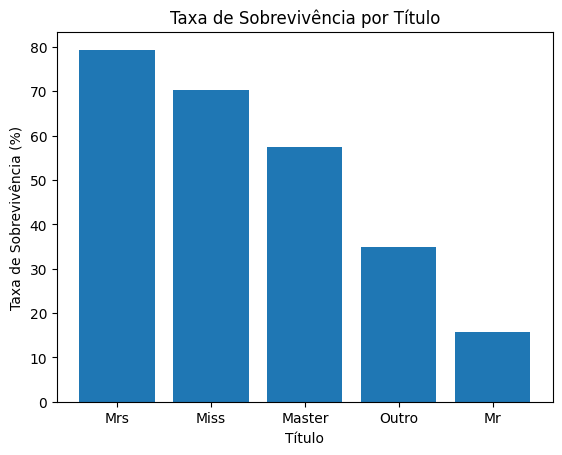

In [789]:
# Calcular a proporção (%) de sobreviventes por Título
sobreviventes_por_titulo = (
    df.groupby('Titulo')['Sobreviveu']
    .value_counts(normalize=True)
    .unstack() * 100
)

# Renomeando e Ordenando
sobreviventes_por_titulo = (
    sobreviventes_por_titulo
    .rename(columns={0: 'Mortos', 1: 'Sobreviventes (%)'})
    .sort_values(by='Sobreviventes (%)', ascending=False)
)

# Criando gráfico com a taxa de sobrevivência.
plt.bar(sobreviventes_por_titulo.index, sobreviventes_por_titulo['Sobreviventes (%)'])
plt.xlabel('Título')
plt.ylabel('Taxa de Sobrevivência (%)')
plt.title('Taxa de Sobrevivência por Título')
plt.show()

## Qual a porcentagem se sobrevivência por Tipo de Classe

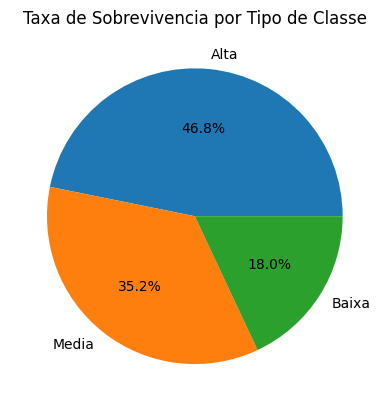

In [790]:
# Calculando a taxa de sobrevivência por Tipo de Classe
sobreviventes_por_classe = (
    df.groupby('Tipo_classe')['Sobreviveu']
    .value_counts(normalize=True)
    .unstack() * 100
)

# Renomeando e Ordenando
sobreviventes_por_classe = (
    sobreviventes_por_classe
    .rename(columns={0: 'Mortos', 1: 'Sobreviventes (%)'})
    .sort_values(by='Sobreviventes (%)', ascending=False)
)

# Criando gráfico com a taxa de sobrevivencia
plt.pie(sobreviventes_por_classe['Sobreviventes (%)'], labels=sobreviventes_por_classe.index, autopct='%1.1f%%')
plt.title('Taxa de Sobrevivencia por Tipo de Classe')
plt.show()

## Qual sexo teve mais sobreviventes


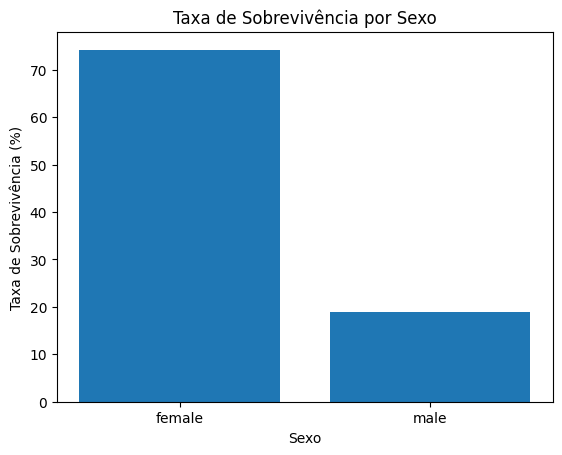

In [791]:
# Calculando a taxa de sobrevivencia por Genero
sobreviventes_por_genero = (
    df.groupby('Sexo')['Sobreviveu']
    .value_counts(normalize=True)
    .unstack() * 100
)

# Renomeando e Ordenando
sobreviventes_por_genero = (
    sobreviventes_por_genero
    .rename(columns={0: 'Mortos', 1: 'Sobreviventes (%)'})
    .sort_values(by='Sobreviventes (%)', ascending=False)
)

# Criando gráfico com a taxa de sobrevivência
plt.bar(sobreviventes_por_genero.index, sobreviventes_por_genero['Sobreviventes (%)'])
plt.xlabel('Sexo')
plt.ylabel('Taxa de Sobrevivência (%)')
plt.title('Taxa de Sobrevivência por Sexo')
plt.show()

## Quais Faixas Etarias mais sobreviveram em porcentagem %

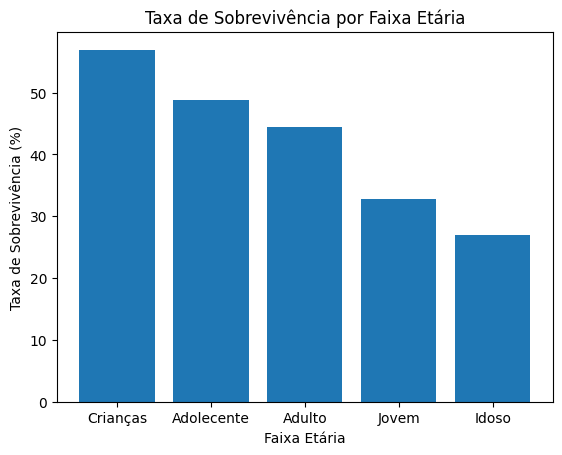

In [792]:
# Calcular a proporção (%) de sobreviventes por faixa etária
sobreviventes_por_idade = (
    df.groupby('Faixa_etaria')['Sobreviveu']
    .value_counts(normalize=True)
    .unstack() * 100
)

# Renomeado e ordenando.
sobreviventes_por_idade = (
    sobreviventes_por_idade
    .rename(columns={0: 'Mortos', 1: 'Sobreviventes (%)'})
    .sort_values(by='Sobreviventes (%)', ascending=False)
)

# Criando um gráfico com a taxa de sobrevivência
plt.bar(sobreviventes_por_idade.index, sobreviventes_por_idade['Sobreviventes (%)'])
plt.xlabel('Faixa Etária')
plt.ylabel('Taxa de Sobrevivência (%)')
plt.title('Taxa de Sobrevivência por Faixa Etária')
plt.show()


## Quais Tamanhos de Familia mais sobreviveram em %

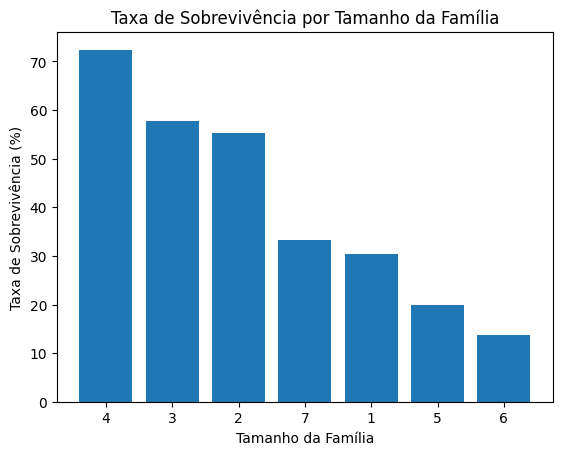

In [793]:
# Calculando a proporção de sobreviventes por tamanho de familia
sobreviventes_por_familia = (
    df.groupby('Tamanho_familia')['Sobreviveu']
    .value_counts(normalize=True)
    .unstack() * 100
)

# Renomeando e Ordenando
sobreviventes_por_familia = (
    sobreviventes_por_familia
    .rename(columns={0: 'Mortos', 1: 'Sobreviventes (%)'})
    .sort_values(by='Sobreviventes (%)', ascending=False)
)

sobreviventes_por_familia.head()

# Criando grafico para exibir a taxa de sobrevivência por tamanho da familia
plt.bar(sobreviventes_por_familia.index.astype(str), sobreviventes_por_familia['Sobreviventes (%)'])
plt.xlabel('Tamanho da Família')
plt.ylabel('Taxa de Sobrevivência (%)')
plt.title('Taxa de Sobrevivência por Tamanho da Família')
plt.show()

## Quais Decks tiveram mais sobreviventes

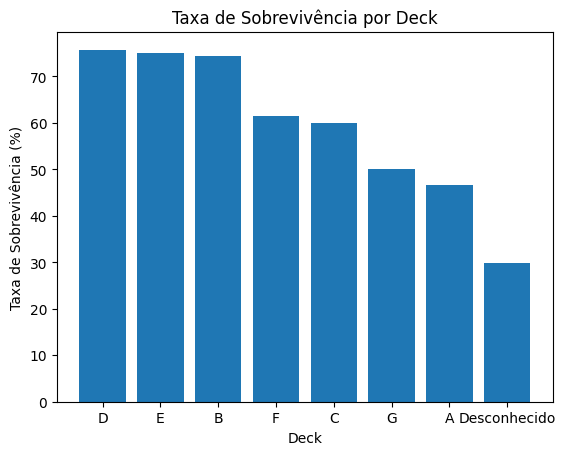

In [794]:
# Calculando a proporção de sobreviventes em cada Deck
sobreviventes_por_deck = (
    df.groupby('Deck')['Sobreviveu']
    .value_counts(normalize=True)
    .unstack() * 100
)

# Renomeado e Ordenando
sobreviventes_por_deck = (
    sobreviventes_por_deck
    .rename(columns={0: 'Mortos', 1: 'Sobreviventes (%)'})
    .sort_values(by='Sobreviventes (%)', ascending=False)
)

# Criando grafico para exibir quais Decks teve mais sobreviventes
plt.bar(sobreviventes_por_deck.index, sobreviventes_por_deck['Sobreviventes (%)'])
plt.xlabel('Deck')
plt.ylabel('Taxa de Sobrevivência (%)')
plt.title('Taxa de Sobrevivência por Deck')
plt.show()

# Informações gerais sobre a tabela.
* Total de Linhas no DataFrame: 891
* Total de Colunas no DataFrame: 12
* Ronemiei todas as colunas para Português.
* Colunas que tem valores nulos:
    * Idade: 177: <pre>Não vou mexer aqui no momento.
    * Cabine: 687: <pre>Tem como recuperar esses dados? Sim, mas só consegui recuperar apenas 1 valor referente<br>ao bilhete 113781, estavem em grupo e apenas um deles não estava com Cabine preenchida.<br>Esse acreditei ser o correto a fazer.
    * Porto_embarque: 2<pre>Não achei nada em comum para poder recuparar os dados.
* Extrai dos nomes os titulos de nobreza:
    * Mr, Miss, Mrs, Masters e o restante ficou com Outros.
* Criei uma coluna que armazena o total de Membros familiares.
* Criei uma coluna que recebe a Inicial do Deck/Cabine:
    * C, B, D, E, A, F, G, T e Desconhecido.
* Criei uma coluna para facilitar a leitura do Tipo de Classe:
    * | 1: Alta | 2: Media | 3: Baixa |
* Criei uma coluna de Faixa Etária:
    * | Criança | Adolecentes | Jovens | Adultos | Idosos |
    * | ...0-12... | .......12-18...... | .18-35. | ..35-60.. | 60-100 |

In [795]:
!git config --global user.name "LuizPk13"
!git config --global user.email "fernando.adr13pk@gmail.com"

In [796]:
!git init
!git branch -M main
!git remote add origin https://github.com/LuizPk13/titanic-eda.git
!git remote -v

Reinitialized existing Git repository in /content/drive/MyDrive/Colab Notebooks/SCTEC - Materiais e Projetos/Testes de Análises/titanic/.git/
error: remote origin already exists.
origin	https://github.com/LuizPk13/titanic-eda.git (fetch)
origin	https://github.com/LuizPk13/titanic-eda.git (push)


In [797]:
!git add .
!git commit -m "Primeiro commit - Titanic EDA"

[main 83a3d03] Primeiro commit - Titanic EDA
 1 file changed, 1 insertion(+), 1 deletion(-)


In [798]:
!git push --set-upstream origin main

fatal: could not read Username for 'https://github.com': No such device or address
